In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.simplefilter("ignore")

In [ ]:
df = pd.read_csv('creditos.csv')
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, count to max
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   edad     8 non-null      float64
 1   credito  8 non-null      float64
 2   cumplio  8 non-null      float64
dtypes: float64(3)
memory usage: 256.0+ bytes


In [7]:
paga = df[df["cumplio"]==1]
no_paga = df[df["cumplio"]==0]

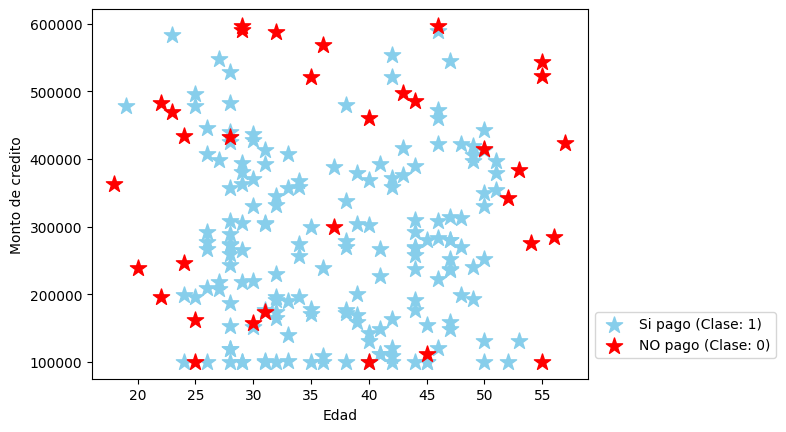

[[0.         0.52964444]
 [0.02564103 0.76084353]
 [0.05128205 0.27995193]
 [0.1025641  0.19176844]
 [0.1025641  0.76931624]
 [0.12820513 0.74242458]
 [0.12820513 0.97341632]
 [0.15384615 0.        ]
 [0.15384615 0.19983453]
 [0.15384615 0.29429053]
 [0.15384615 0.67122276]
 [0.17948718 0.        ]
 [0.17948718 0.12374716]
 [0.17948718 0.19192143]
 [0.17948718 0.76130249]
 [0.17948718 0.79673129]
 [0.20512821 0.        ]
 [0.20512821 0.21862589]
 [0.20512821 0.33577846]
 [0.20512821 0.35571521]
 [0.20512821 0.38628463]
 [0.20512821 0.61926119]
 [0.20512821 0.69480706]
 [0.23076923 0.21664509]
 [0.23076923 0.23805134]
 [0.23076923 0.60140789]
 [0.23076923 0.90058196]
 [0.25641026 0.        ]
 [0.25641026 0.03816245]
 [0.25641026 0.03904616]
 [0.25641026 0.10798336]
 [0.25641026 0.17607107]
 [0.25641026 0.28867627]
 [0.25641026 0.32202564]
 [0.25641026 0.3484986 ]
 [0.25641026 0.35193882]
 [0.25641026 0.38080524]
 [0.25641026 0.42070089]
 [0.25641026 0.51803547]
 [0.25641026 0.65311582]


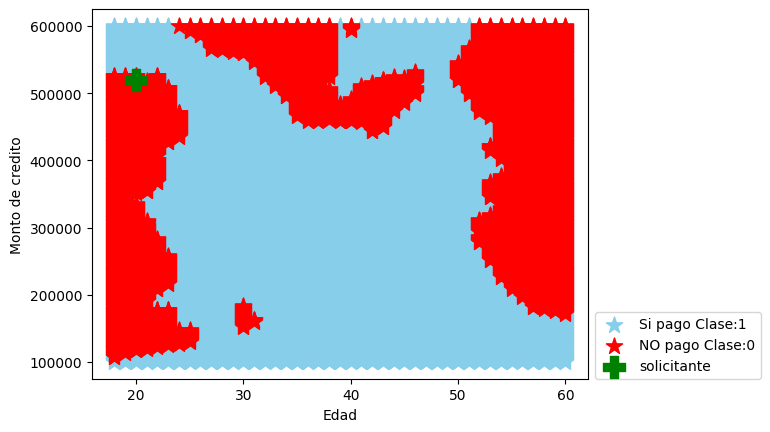

In [8]:
#Grafica de paga vs no_paga

plt.scatter(paga['edad'], paga['credito'],     # <-- Corregido
            marker = "*", s = 150, color = "skyblue",
            label = "Si pago (Clase: 1)")

plt.scatter(no_paga['edad'], no_paga['credito'], # <-- Corregido
            marker = "*", s = 150, color = "red",
            label = "NO pago (Clase: 0)")

plt.ylabel("Monto de credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()

from sklearn.preprocessing import MinMaxScaler # <-- 1. Importa la clase

# Preprocesamiento
datos = df[["edad", "credito"]]
clase = df["cumplio"]

escalador = MinMaxScaler() # <-- 2. Crea la instancia (sin el prefijo)

datos = escalador.fit_transform(datos)
print(datos)

#creando el modelo KNN
clasificador = KNeighborsClassifier(n_neighbors=3)
clasificador.fit(datos,clase)

edad = 20
monto = 520000

#Escalar los datos del nuevo solicitante
solicitante = escalador.transform([[edad, monto]])

#Calcular clase y probabilidades
print("Clase:", clasificador.predict(solicitante))

print("Probabilidades por clase:", clasificador.predict_proba(solicitante))



#Regiones de la clase
#Datos sinteticos de todos los posibles solicitantes
creditos = np.array([np.arange(100000, 600010,1000)]* 43).reshape(1, -1)
edades = np.array([np.arange(18,61)]*501).reshape(1,-1)
todos = pd.DataFrame(np.stack((edades,creditos), axis =2) [0], columns=["edad", "credito"])

#escalar datos
solicitantes = escalador.transform(todos)

#predecir todas las clases
clases_resultantes = clasificador.predict(solicitantes)

#Codigo para graficar
paga = todos[clases_resultantes==1]
no_paga = todos[clases_resultantes==0]


plt.scatter(paga['edad'], paga['credito'],
            marker = '*', s =150, color = "skyblue", label= "Si pago Clase:1")

plt.scatter(no_paga['edad'], no_paga['credito'],
            marker = '*', s =150, color = "red", label= "NO pago Clase:0")

plt.scatter(edad, monto, marker = "P", s = 250, color = "green", label = "solicitante")

plt.ylabel("Monto de credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.2))
plt.show()

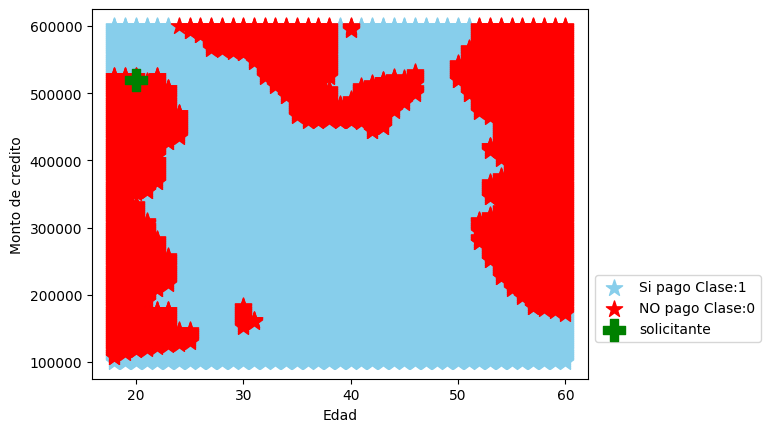

In [9]:
#Codigo para graficar
plt.scatter(paga['edad'], paga['credito'],
            marker = '*', s =150, color = "skyblue", label= "Si pago Clase:1")

plt.scatter(no_paga['edad'], no_paga['credito'],
            marker = '*', s =150, color = "red", label= "NO pago Clase:0")

plt.scatter(edad, monto, marker = "P", s = 250, color = "green", label = "solicitante")

plt.ylabel("Monto de credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.3))
plt.show()

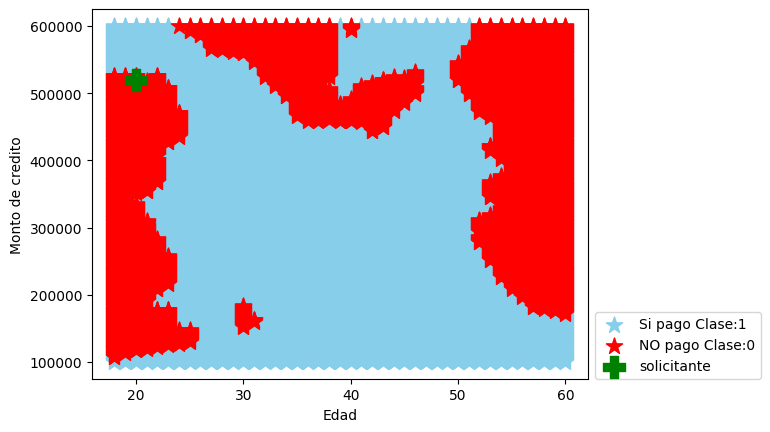

In [10]:
#Regiones de la clase
#Datos sinteticos de todos los posibles solicitantes
creditos = np.array([np.arange(100000, 600010,1000)]* 43).reshape(1, -1)
edades = np.array([np.arange(18,61)]*501).reshape(1,-1)
todos = pd.DataFrame(np.stack((edades,creditos), axis =2) [0], columns=["edad", "credito"])

#escalar datos
solicitantes = escalador.transform(todos)

#predecir todas las clases
clases_resultantes = clasificador.predict(solicitantes)

#Codigo para graficar
paga = todos[clases_resultantes==1]
no_paga = todos[clases_resultantes==0]


plt.scatter(paga['edad'], paga['credito'],
            marker = '*', s =150, color = "skyblue", label= "Si pago Clase:1")

plt.scatter(no_paga['edad'], no_paga['credito'],
            marker = '*', s =150, color = "red", label= "NO pago Clase:0")

plt.scatter(edad, monto, marker = "P", s = 250, color = "green", label = "solicitante")

plt.ylabel("Monto de credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.2))
plt.show()